In [2]:
# coding: utf-8
 
import cv2
import numpy as np
import os
from sklearn.cluster  import KMeans
from matplotlib import pyplot as plt
# get_ipython().magic('matplotlib inline')
 
 
# ### 基于SIFT,BOW的图像检索
# #### 1、SIFT提取每幅图像的特征点
# #### 2、聚类获取视觉单词中心（聚类中心），构造视觉单词词典
# #### 3、将图像特征点映射到视觉单词上，得到图像特征
# #### 4、计算待检索图像的最近邻图像
 
#  根据图像数据文件夹路径获取所有图片路径
 
def get_img_path(training_path):
    training_names=os.listdir(training_path)
    # 保留所有图片
 
    img_paths=[]   # 所有图片路径
    for i in training_names:
        k = training_path+i+'/'
        names = os.listdir(k)
        for name in names:
            img_path=os.path.join(k,name)
            img_paths.append(img_path)
    return img_paths
 
 
def getClusterCentures(img_paths,dataset_matrix,num_words):
    '''
    获取聚类中心
    
    img_paths:图像数据中所有图像路径
    dataset_matrix：图像数据的矩阵表示   注：img_paths dataset_matrix这两个参数只需要指定一个
    num_words:聚类中心数
    '''
    des_list=[]  # 特征描述
    des_matrix=np.zeros((1,128))
    sift_det=cv2.SIFT_create()
    if img_paths!=None:
        for path in img_paths:
            img=cv2.imread(path)
            print(path)
            # 
            # img = cv2.resize(img, (400, 400))
            if path :
                gray=img
                kp,des=sift_det.detectAndCompute(gray,None)
                if des!=[]:
                    des_matrix=np.row_stack((des_matrix,des))
                des_list.append(des)
    elif dataset_matrix!=None:
        for gray in range(dataset_matrix.shape[0]):
            kp,des=sift_det.detectAndCompute(gray,None)
            if des!=[]:
                des_matrix=np.row_stack((des_matrix,des))
            des_list.append(des)
    else:
        raise ValueError('输入不合法')
    
    des_matrix=des_matrix[1:,:]   # the des matrix of sift
 
    # 计算聚类中心  构造视觉单词词典
    kmeans=KMeans(n_clusters=num_words,random_state=33)
    kmeans.fit(des_matrix)
    centres = kmeans.cluster_centers_  # 视觉聚类中心
    
    return centres,des_list
 
# 将特征描述转换为特征向量
def des2feature(des,num_words,centures):
    '''
    des:单幅图像的SIFT特征描述
    num_words:视觉单词数/聚类中心数
    centures:聚类中心坐标   num_words*128
    return: feature vector 1*num_words
    '''
    img_feature_vec=np.zeros((1,num_words),'float32')
    for i in range(des.shape[0]):
        feature_k_rows=np.ones((num_words,128),'float32')
        feature=des[i]
        feature_k_rows=feature_k_rows*feature
        feature_k_rows=np.sum((feature_k_rows-centures)**2,1)
        index=np.argmax(feature_k_rows)
        img_feature_vec[0][index]+=1
    return img_feature_vec
 
def get_all_features(des_list,num_words):
    # 获取所有图片的特征向量
    allvec=np.zeros((len(des_list),num_words),'float32')
    for i in range(len(des_list)):
        if des_list[i]!=[]:
            allvec[i]=des2feature(centures=centres,des=des_list[i],num_words=num_words)
    return allvec
 
def getNearestImg(feature,dataset,num_close):
    '''
    找出目标图像最像的几个
    feature:目标图像特征
    dataset:图像数据库
    num_close:最近个数
    return:最相似的几个图像
    '''
    features=np.ones((dataset.shape[0],len(feature)),'float32')
    features=features*feature
    dist=np.sum((features-dataset)**2,1)
    dist_index=np.argsort(dist)
    return dist_index[:num_close]
 
 
def showImg(target_img_path,index,dataset_paths):
    '''
    target_img:要搜索的图像
    dataset_paths：图像数据库所有图片的路径
    显示最相似的图片集合
    '''
    # get img path
    paths=[]
    for i in index:
        paths.append(dataset_paths[i])
        
    plt.figure(figsize=(10,20))    #  figsize 用来设置图片大小
    plt.subplot(432),plt.imshow(plt.imread(target_img_path)),plt.title('target_image')
    
    for i in range(len(index)):
        plt.subplot(4,3,i+4),plt.imshow(plt.imread(paths[i]))
    plt.show()
 
 
# 暴力搜索
def retrieval_img(img_path,img_dataset,centures,img_paths):
    '''
    检索图像，找出最像的几个
    img:待检索的图像
    img_dataset:图像数据库 matrix
    num_close:显示最近邻的图像数目
    centures:聚类中心
    img_paths:图像数据库所有图像路径
    '''
    num_close=9
    print(img_path)
    img=cv2.imread(img_path)
    print(img)
    sift_det=cv2.SIFT_create()
    kp,des=sift_det.detectAndCompute(img,None)
    feature=des2feature(des=des,centures=centures,num_words=num_words)
    sorted_index=getNearestImg(feature,img_dataset,num_close)
    
    showImg(img_path,sorted_index,img_paths)
 
 
# test
# 或者文件中的所有图像
img_paths = get_img_path('D:/images/')
num_words=30 # 聚类中心数
# 得到质心， 和所有样本的sift特征。
centres,des_list=getClusterCentures(img_paths=img_paths,num_words=num_words,dataset_matrix=None)
# 获取所有训练样本的特征。
img_features=get_all_features(des_list=des_list,num_words=num_words)
 
# 对新来的样本和已有样本进行相似度检索。
path='./Image_40.jpeg'
retrieval_img(path,img_features,centres,img_paths)
 
pic=plt.imread(path)
plt.figure(figsize=(10,20))
plt.imshow(pic)
plt.show()

D:/images/apple/Image_1.jpg


d:\Anaconda3\envs\pytorch\lib\site-packages\ipykernel_launcher.py:53: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


D:/images/apple/Image_10.jpg
D:/images/apple/Image_11.jpg
D:/images/apple/Image_12.jpg
D:/images/apple/Image_13.png
D:/images/apple/Image_14.png
D:/images/apple/Image_15.jpg
D:/images/apple/Image_16.jpg
D:/images/apple/Image_17.jpeg
D:/images/apple/Image_18.jpg
D:/images/apple/Image_19.jpg


error: OpenCV(4.6.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 384000000 bytes in function 'cv::OutOfMemoryError'


d:\Anaconda3\envs\pytorch\lib\site-packages\ipykernel_launcher.py:53: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
d:\Anaconda3\envs\pytorch\lib\site-packages\ipykernel_launcher.py:96: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.


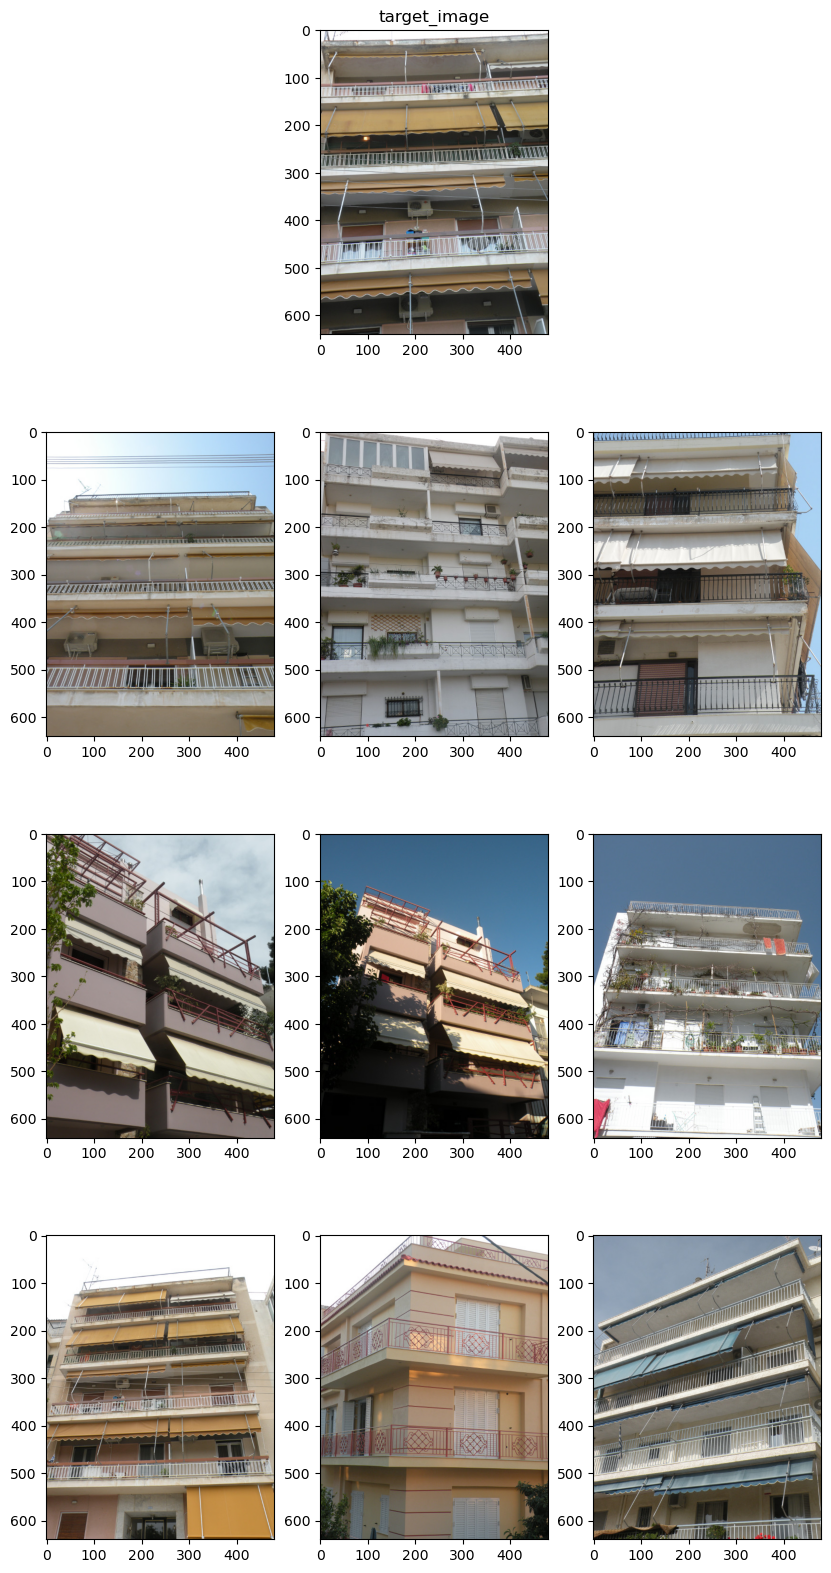

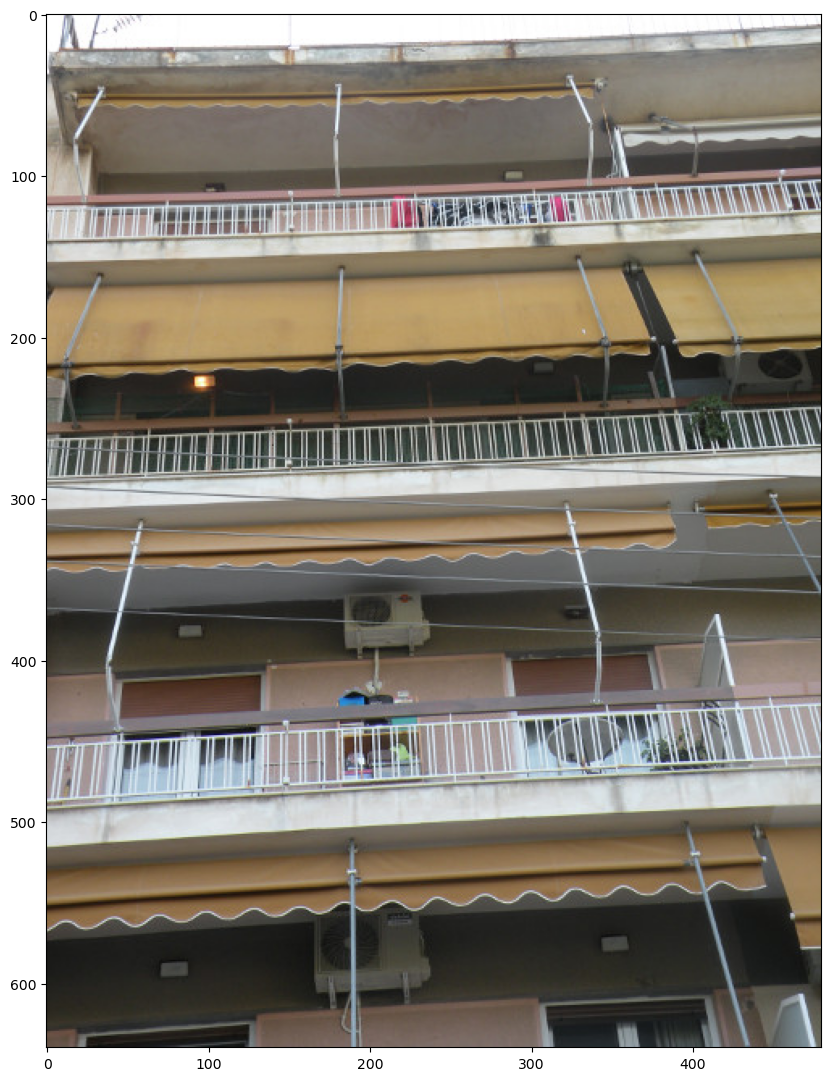

In [19]:
# coding: utf-8
 
import cv2
import numpy as np
import os
from sklearn.cluster  import KMeans
from matplotlib import pyplot as plt
# get_ipython().magic('matplotlib inline')
 
 
# ### 基于SIFT,BOW的图像检索
# #### 1、SIFT提取每幅图像的特征点
# #### 2、聚类获取视觉单词中心（聚类中心），构造视觉单词词典
# #### 3、将图像特征点映射到视觉单词上，得到图像特征
# #### 4、计算待检索图像的最近邻图像
 
#  根据图像数据文件夹路径获取所有图片路径
 
def get_img_path(training_path):
    training_names=os.listdir(training_path)
    # 保留所有图片
    pic_names=['bmp','jpg','png','tiff','gif','pcx','tga','exif','fpx','svg','psd','cdr','pcd','dxf','ufo','eps','ai','raw','WMF']
    for name in training_names:
        file_format=name.split('.')[-1]
        if file_format not in pic_names:
            training_names.remove(name)
 
    img_paths=[]   # 所有图片路径
    for name in training_names:
        img_path=os.path.join(training_path,name)
        img_paths.append(img_path)
    return img_paths
 
 
def getClusterCentures(img_paths,dataset_matrix,num_words):
    '''
    获取聚类中心
    
    img_paths:图像数据中所有图像路径
    dataset_matrix：图像数据的矩阵表示   注：img_paths dataset_matrix这两个参数只需要指定一个
    num_words:聚类中心数
    '''
    des_list=[]  # 特征描述
    des_matrix=np.zeros((1,128))
    sift_det=cv2.SIFT_create()
    if img_paths!=None:
        for path in img_paths:
            img=cv2.imread(path)
            # 
            # img = cv2.resize(img, (400, 400))
            gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
            kp,des=sift_det.detectAndCompute(gray,None)
            if des!=[]:
                des_matrix=np.row_stack((des_matrix,des))
            des_list.append(des)
    elif dataset_matrix!=None:
        for gray in range(dataset_matrix.shape[0]):
            kp,des=sift_det.detectAndCompute(gray,None)
            if des!=[]:
                des_matrix=np.row_stack((des_matrix,des))
            des_list.append(des)
    else:
        raise ValueError('输入不合法')
    
    des_matrix=des_matrix[1:,:]   # the des matrix of sift
 
    # 计算聚类中心  构造视觉单词词典
    kmeans=KMeans(n_clusters=num_words,random_state=33)
    kmeans.fit(des_matrix)
    centres = kmeans.cluster_centers_  # 视觉聚类中心
    
    return centres,des_list
 
# 将特征描述转换为特征向量
def des2feature(des,num_words,centures):
    '''
    des:单幅图像的SIFT特征描述
    num_words:视觉单词数/聚类中心数
    centures:聚类中心坐标   num_words*128
    return: feature vector 1*num_words
    '''
    img_feature_vec=np.zeros((1,num_words),'float32')
    for i in range(des.shape[0]):
        feature_k_rows=np.ones((num_words,128),'float32')
        feature=des[i]
        feature_k_rows=feature_k_rows*feature
        feature_k_rows=np.sum((feature_k_rows-centures)**2,1)
        index=np.argmax(feature_k_rows)
        img_feature_vec[0][index]+=1
    return img_feature_vec
 
def get_all_features(des_list,num_words):
    # 获取所有图片的特征向量
    allvec=np.zeros((len(des_list),num_words),'float32')
    for i in range(len(des_list)):
        if des_list[i]!=[]:
            allvec[i]=des2feature(centures=centres,des=des_list[i],num_words=num_words)
    return allvec
 
def getNearestImg(feature,dataset,num_close):
    '''
    找出目标图像最像的几个
    feature:目标图像特征
    dataset:图像数据库
    num_close:最近个数
    return:最相似的几个图像
    '''
    features=np.ones((dataset.shape[0],len(feature)),'float32')
    features=features*feature
    dist=np.sum((features-dataset)**2,1)
    dist_index=np.argsort(dist)
    return dist_index[:num_close]
 
 
def showImg(target_img_path,index,dataset_paths):
    '''
    target_img:要搜索的图像
    dataset_paths：图像数据库所有图片的路径
    显示最相似的图片集合
    '''
    # get img path
    paths=[]
    for i in index:
        paths.append(dataset_paths[i])
        
    plt.figure(figsize=(10,20))    #  figsize 用来设置图片大小
    plt.subplot(432),plt.imshow(plt.imread(target_img_path)),plt.title('target_image')
    
    for i in range(len(index)):
        plt.subplot(4,3,i+4),plt.imshow(plt.imread(paths[i]))
    plt.show()
 
 
# 暴力搜索
def retrieval_img(img_path,img_dataset,centures,img_paths):
    '''
    检索图像，找出最像的几个
    img:待检索的图像
    img_dataset:图像数据库 matrix
    num_close:显示最近邻的图像数目
    centures:聚类中心
    img_paths:图像数据库所有图像路径
    '''
    num_close=9
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    sift_det=cv2.SIFT_create()
    kp,des=sift_det.detectAndCompute(img,None)
    feature=des2feature(des=des,centures=centures,num_words=num_words)
    sorted_index=getNearestImg(feature,img_dataset,num_close)
    
    showImg(img_path,sorted_index,img_paths)
 
 
# test
# 或者文件中的所有图像
img_paths = get_img_path('./Vyronasdbmin/')
num_words=20  # 聚类中心数
# 得到质心， 和所有样本的sift特征。
centres,des_list=getClusterCentures(img_paths=img_paths,num_words=num_words,dataset_matrix=None)
# 获取所有训练样本的特征。
img_features=get_all_features(des_list=des_list,num_words=num_words)
 
# 对新来的样本和已有样本进行相似度检索。
path='building01_zoom_noon.jpg'
retrieval_img(path,img_features,centres,img_paths)
 
pic=plt.imread(path)
plt.figure(figsize=(10,20))
plt.imshow(pic)
plt.show()

In [2]:
import pandas as pd
import jieba.analyse
from wordcloud import WordCloud
import cv2
f = open('D:/微信/WeChat Files/wxid_r5kq4d5lmfod22/FileStorage/File/2023-05/qa_pair.txt',"r", encoding='UTF-8').read()
"""text = []
for i in f.readlines():
    if len(i) == 1:
        continue
    text.append(i)"""
# 切割分词
wordlist = jieba.cut(f)
result = ' '.join(wordlist)
# 设置停用词
stop_words = ['你', '我', '的', '了', '们','有','在','和','或']
ciyun_words = ''
 
 
for word in wordlist:
    if word not in stop_words and len(word)>1:
        ciyun_words += word
# 读取图片
#im = cv2.imread('11.jpg')
# 设置参数，创建WordCloud对象
wc = WordCloud(
    font_path='D:/下载/SimHei.ttf',       # 中文
    background_color='white',    # 设置背景颜色为白色
    stopwords=stop_words
)
# 根据文本数据生成词云
wc.generate(ciyun_words)
# 保存词云文件
wc.to_file('img.jpg')

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [2]:
print(a)

['如何', '办理', '企业', '养老保险', '\t', '企业', '养老保险', '一般', '是', '交由', '企业', '办理', '，', '个人', '需要', '准备', '好', '相关', '的', '文件', '即可', '。', '个人', '在', '参加', '企业', '养老保险', '的', '时候', '，', '需', '填报', '《', '参加', '企业', '基本', '养老保险', '人员', '基本', '情况表', '》', '，', '并', '提供', '以下', '证件', '和', '主要', '资料', '：', '1', '、', '身份证件', '及', '复印件', '；', '2', '、', '户口簿', '及', '复印件', '；', '3', '、', '以', '个人身份', '参保', '前原', '为', '职工', '身份', '的', '本人', '档案', '材料', '；', '4', '、', '曾', '在', '其他', '统筹', '地区', '参保', '的', '，', '重新', '登记', '应', '提供', '原', '参保', '所在地', '社保', '机构', '开具', '的', '《', '基本', '养老保险', '关系', '转移', '表', '》', '；', '5', '、', '与', '单位', '解除', '劳动', '关系', '的', '，', '应', '提供', '相关', '证明', '；', '6', '、', '省', '社保', '机构', '规定', '的', '其他', '证件', '资料', '。', '企业', '缴费', '以', '职工', '工资总额', '为', '基数', '，', '缴费', '比例', '为', '20%', '；', '职工', '个人', '缴费', '以', '本人', '全部', '工资收入', '为', '基数', '，', '月', '缴费', '工资', '超过', '全省', '上', '一', '年度', '职工', '平均工资', '300%', '以上', '的', '部分', '不', '计入', '，', '低于', '60%', '的', '